# 3. Model Training

Models:
- Deep Neural Network (DNN)
- Convolutional Neural Network (CNN)
- Long Short-Term Memory (LSTM)
- Convolutional Long Short-Term Memory (CLSTM)
- Transformer Encoder (TE)

In [2]:
# imports
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Drone print

In [4]:
# Load features
X = np.load("features/X_mfcc.npy")
y = np.load("features/y_labels.npy")

print("Loaded:", X.shape, y.shape)

Loaded: (2082, 86, 40) (2082,)


## 1.1 - Train/Val/Test split

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# Convert to PyTorch tensors
def to_tensor(x, y):
    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)
    return TensorDataset(x, y)

train_ds = to_tensor(X_train, y_train)
val_ds   = to_tensor(X_val, y_val)
test_ds  = to_tensor(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32)
test_dl  = DataLoader(test_ds, batch_size=32)

Train: (1457, 86, 40)
Val: (312, 86, 40)
Test: (313, 86, 40)


## 1.2 - LSTM model definition

In [6]:
class DroneRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=40,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # last time step
        return out

model = DroneRNN()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

print(model)


DroneRNN(
  (lstm): LSTM(40, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


## 1.3 - LSTM model definition

In [7]:
EPOCHS = 40
best_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_lstm_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1: Train Loss = 18.9755, Val Loss = 0.8358
Epoch 2: Train Loss = 0.8880, Val Loss = 0.0444
Epoch 3: Train Loss = 0.1380, Val Loss = 0.0207
Epoch 4: Train Loss = 0.0753, Val Loss = 0.0128
Epoch 5: Train Loss = 0.0495, Val Loss = 0.0089
Epoch 6: Train Loss = 0.0358, Val Loss = 0.0066
Epoch 7: Train Loss = 0.0272, Val Loss = 0.0052
Epoch 8: Train Loss = 0.0215, Val Loss = 0.0041
Epoch 9: Train Loss = 0.0174, Val Loss = 0.0034
Epoch 10: Train Loss = 0.0145, Val Loss = 0.0028
Epoch 11: Train Loss = 0.0123, Val Loss = 0.0024
Epoch 12: Train Loss = 0.0106, Val Loss = 0.0021
Epoch 13: Train Loss = 0.0092, Val Loss = 0.0018
Epoch 14: Train Loss = 0.0081, Val Loss = 0.0016
Epoch 15: Train Loss = 0.0072, Val Loss = 0.0014
Epoch 16: Train Loss = 0.0065, Val Loss = 0.0013
Epoch 17: Train Loss = 0.0058, Val Loss = 0.0012
Epoch 18: Train Loss = 0.0052, Val Loss = 0.0011
Epoch 19: Train Loss = 0.0048, Val Loss = 0.0010
Epoch 20: Train Loss = 0.0044, Val Loss = 0.0009
Epoch 21: Train Loss = 0.004

## 1.4 - Training loop with early stopping

In [8]:
EPOCHS = 40
best_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_lstm_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1: Train Loss = 0.0012, Val Loss = 0.0002
Epoch 2: Train Loss = 0.0012, Val Loss = 0.0002
Epoch 3: Train Loss = 0.0011, Val Loss = 0.0002
Epoch 4: Train Loss = 0.0011, Val Loss = 0.0002
Epoch 5: Train Loss = 0.0010, Val Loss = 0.0002
Epoch 6: Train Loss = 0.0010, Val Loss = 0.0002
Epoch 7: Train Loss = 0.0009, Val Loss = 0.0002
Epoch 8: Train Loss = 0.0009, Val Loss = 0.0002
Epoch 9: Train Loss = 0.0009, Val Loss = 0.0002
Epoch 10: Train Loss = 0.0008, Val Loss = 0.0002
Epoch 11: Train Loss = 0.0008, Val Loss = 0.0002
Epoch 12: Train Loss = 0.0008, Val Loss = 0.0002
Epoch 13: Train Loss = 0.0007, Val Loss = 0.0002
Epoch 14: Train Loss = 0.0007, Val Loss = 0.0001
Epoch 15: Train Loss = 0.0007, Val Loss = 0.0001
Epoch 16: Train Loss = 0.0007, Val Loss = 0.0001
Epoch 17: Train Loss = 0.0006, Val Loss = 0.0001
Epoch 18: Train Loss = 0.0006, Val Loss = 0.0001
Epoch 19: Train Loss = 0.0006, Val Loss = 0.0001
Epoch 20: Train Loss = 0.0006, Val Loss = 0.0001
Epoch 21: Train Loss = 0.0006

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       201
           1     1.0000    1.0000    1.0000       112

    accuracy                         1.0000       313
   macro avg     1.0000    1.0000    1.0000       313
weighted avg     1.0000    1.0000    1.0000       313



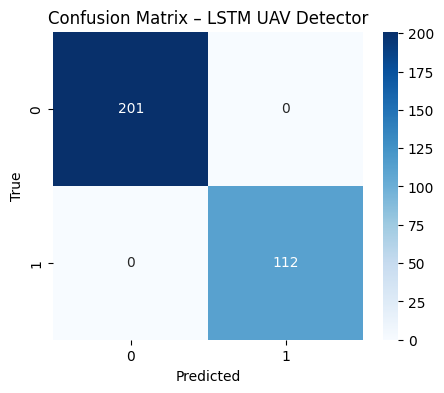

In [9]:
model.load_state_dict(torch.load("best_lstm_model.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(yb.numpy())

print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – LSTM UAV Detector")
plt.show()